In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np



In [2]:
df = pd.read_csv('paddydataset.csv')
X = df.drop('Paddy yield(in Kg)', axis=1)
y = df['Paddy yield(in Kg)']

In [3]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

In [7]:
models = {
    'Multiple Linear Regression': LinearRegression(),
    'Support Vector Regression': TransformedTargetRegressor(regressor=SVR(kernel='rbf'), transformer=StandardScaler()),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': GradientBoostingRegressor(random_state=42)
}

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
print("--- model result ---")
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)       # 訓練
    y_pred = pipeline.predict(X_test)    # 預測

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # ✅ fixed
    print(f"{name} -> R-squared: {r2:.4f}, RMSE: {rmse:.2f}")

--- model result ---
Multiple Linear Regression -> R-squared: 0.9891, RMSE: 942.15
Support Vector Regression -> R-squared: 0.9904, RMSE: 884.14
Random Forest -> R-squared: 0.9903, RMSE: 887.05
XGBoost -> R-squared: 0.9916, RMSE: 826.33


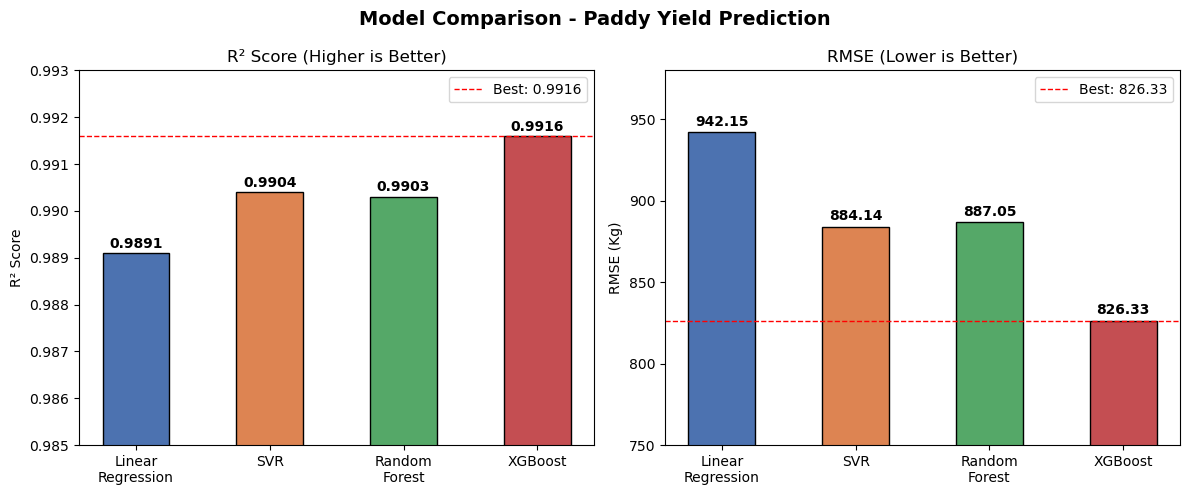

In [12]:
import matplotlib.pyplot as plt
import numpy as np


model_names = ['Linear\nRegression', 'SVR', 'Random\nForest', 'XGBoost']
r2_scores = [0.9891, 0.9904, 0.9903, 0.9916]
rmse_scores = [942.15, 884.14, 887.05, 826.33]

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Comparison - Paddy Yield Prediction', fontsize=14, fontweight='bold')

# --- Picture 1: R² Bar Chart ---
bars1 = axes[0].bar(model_names, r2_scores, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('R² Score (Higher is Better)', fontsize=12)
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0.985, 0.993)
axes[0].axhline(y=max(r2_scores), color='red', linestyle='--', linewidth=1, label=f'Best: {max(r2_scores)}')
axes[0].legend()
for bar, val in zip(bars1, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Picture 2: RMSE Bar Chart ---
bars2 = axes[1].bar(model_names, rmse_scores, color=colors, edgecolor='black', width=0.5)
axes[1].set_title('RMSE (Lower is Better)', fontsize=12)
axes[1].set_ylabel('RMSE (Kg)')
axes[1].set_ylim(750, 980)
axes[1].axhline(y=min(rmse_scores), color='red', linestyle='--', linewidth=1, label=f'Best: {min(rmse_scores)}')
axes[1].legend()
for bar, val in zip(bars2, rmse_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()